In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip chest_xray.zip

Archive:  chest_xray.zip
   creating: chest_xray/
   creating: chest_xray/test/
   creating: chest_xray/test/NORMAL/
  inflating: chest_xray/test/NORMAL/IM-0005-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0006-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0007-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0009-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0010-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001-0002.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0013-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0015-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0016-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0017-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0019-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0021-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0022-0001.jpeg  
  inflating: chest_xray/test/NORM

In [ ]:
!ls

chest_xray  chest_xray.zip  drive  sample_data


In [ ]:
!ls chest_xray

test  train


In [ ]:
!ls chest_xray/train

NORMAL	PNEUMONIA


In [ ]:
train_dir="/content/chest_xray/train"
test_dir="/content/chest_xray/test"

In [ ]:
!ls chest_xray/train/NORMAL | wc -l
!ls chest_xray/train/PNEUMONIA | wc -l
!ls chest_xray/test/NORMAL | wc -l
!ls chest_xray/test/PNEUMONIA | wc -l

400
400
100
100


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=test_gen
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.5030 - loss: 1.3019 - val_accuracy: 0.5600 - val_loss: 0.6675
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.6872 - loss: 0.6186 - val_accuracy: 0.6000 - val_loss: 0.6793
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.7286 - loss: 0.5227 - val_accuracy: 0.6700 - val_loss: 0.5701
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.8232 - loss: 0.3826 - val_accuracy: 0.7700 - val_loss: 0.4691
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.8853 - loss: 0.3065 - val_accuracy: 0.7250 - val_loss: 0.5949
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.8978 - loss: 0.2838 - val_accuracy: 0.7600 - val_loss: 0.4930
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 4s/step - accuracy: 0.9245 - loss: 0.2423 - val_accuracy: 0.7550 - val_loss: 0.5693
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.9092 - loss: 0.2332 - val_accuracy: 0.6700 - va

In [ ]:
model.save("/content/drive/MyDrive/models/pneumonia_model_80_20.h5")
print("Model saved!")


Model saved!


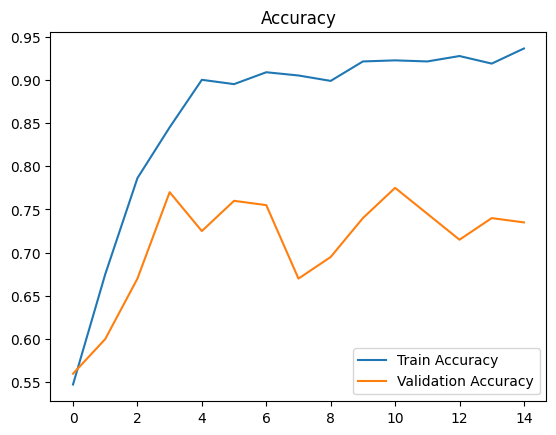

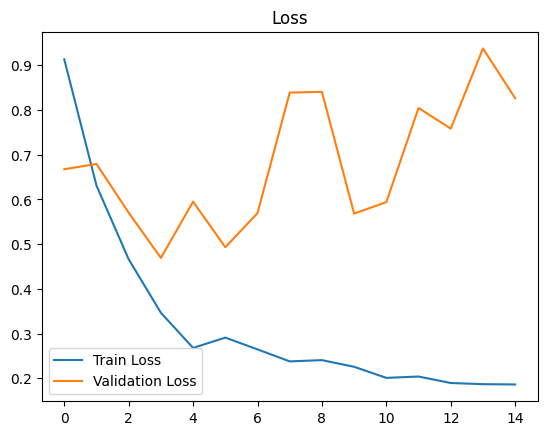

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")
plt.savefig("/content/accuracy_80_20.png")
plt.show()

plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.savefig("/content/loss_80_20.png")
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(test_gen)
pred = (pred > 0.5).astype(int)

cm = confusion_matrix(test_gen.classes, pred)
print(cm)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 729ms/step
[[57 43]
 [10 90]]


In [ ]:
print(classification_report(
    test_gen.classes,
    pred,
    target_names=["Normal","Pneumonia"]
))


              precision    recall  f1-score   support

      Normal       0.85      0.57      0.68       100
   Pneumonia       0.68      0.90      0.77       100

    accuracy                           0.73       200
   macro avg       0.76      0.73      0.73       200
weighted avg       0.76      0.73      0.73       200



In [ ]:
report = classification_report(
    test_gen.classes,
    pred,
    target_names=["Normal","Pneumonia"]
)

with open("/content/classification_report_80_20.txt","w") as f:
    f.write(report)

print("Report saved!")


Report saved!


In [ ]:
report = classification_report(
    test_gen.classes,
    pred,
    target_names=["Normal","Pneumonia"]
)

with open("/content/classification_report_80_20.txt","w") as f:
    f.write(report)

print("Report saved!")


Report saved!


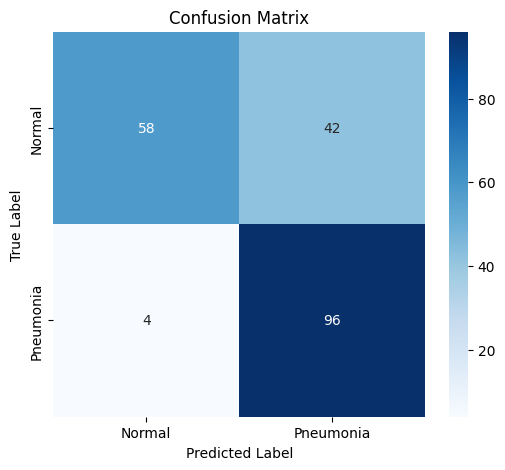

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your confusion matrix values
cm = np.array([[58, 42],
               [4, 96]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Save image
plt.savefig("/content/confusion_matrix_80_20.png")
plt.show()


In [ ]:
from google.colab import files

files.download('/content/confusion_matrix_80_20.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>